# Imports

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import os
import h5py
import static_utils
import pathlib
import pandas as pd
import seaborn as sns
from scipy import stats

%matplotlib inline

In [2]:
%pwd

'/home/lbiswas/Code/gh-prep/mr-tracking-tests-arjun/Static_Tracking'

# Constants and Paths

In [3]:
# Main data paths for each catheter
prepend = '/data' # Change to empty string after zenodo get
parent_path = prepend + '/processed'
if (not os.path.isdir(parent_path)):
    print("Using precomputed outputs")
    parent_path = '../data/preprocessed'

class YLoc:
    def __init__(self, description=None, input_path_suffix=None, export_path_suffix=None):
        self.description = description
        self.in_suffix = input_path_suffix
        self.out_suffix = export_path_suffix
        
y_locations = [YLoc('Y = 45mm','Y0','Y45mm'), YLoc('Y = 20mm','Y1', 'Y20mm'), YLoc('Y = -5mm', 'Y2', 'Y-5mm')]
catheter_labels = ['C222','C231','C306']

main_paths = {} # input coordinate data from each catheter and position
heatmap_paths = {} # exported heatmap plots
xpmt_date_dict = {
    (catheter_labels[0],'Y0'):'17Aug2021',
    (catheter_labels[1],'Y0'):'15Dec2021',
    (catheter_labels[2],'Y0'):'13Dec2021',
    (catheter_labels[0],'Y1'):'8Nov2021',
    (catheter_labels[1],'Y1'):'21Dec2021',
    (catheter_labels[2],'Y1'):'6Jan2022',
    (catheter_labels[0],'Y2'):'9Nov2021',
    (catheter_labels[1],'Y2'):'9Jan2022',
    (catheter_labels[2],'Y2'):'7Jan2022',
}
for yloc in y_locations:
    main_paths[yloc.in_suffix] = []
    for cath in catheter_labels:
        xpmt_date = xpmt_date_dict[(cath,yloc.in_suffix)]
        main_paths[yloc.in_suffix].append(f'{parent_path}/static/trackTest-{xpmt_date}-{cath}-{yloc.in_suffix}/')
    heatmap_paths[yloc.in_suffix] = f'../reports/figures/static/{yloc.out_suffix}/'

# Tip error data is also exported to HDF5 files
error_path = '../reports/export/static/'

Gt_filename = '1GroundTruthCoords.csv'

geometry_index = 1

max_samples = 170

Using precomputed outputs


In [4]:
def get_catheter_from_path(path):
    for c in catheter_labels:
        if c in path:
            return c
    return None

# Error Heatmaps

For each sequence and localization algorithm of interest, plot the heatmap of average tip errors at each position. Each position has recordings from three catheters.

In [5]:
sequences = ['SRI_Original', 'FH512_noDither_gradSpoiled']
algorithms = ['centroid_around_peak', 'jpng']
aggregate_data = []
aggregate_plot = []

os.makedirs(error_path, exist_ok=True)

for yloc in y_locations:
    for seq in sequences:
        for alg in algorithms:
            main_path = main_paths[yloc.in_suffix]
            path_dct = static_utils.get_catheter_data(main_path, seq, alg, Gt_filename, geometry_index, max_samples)
            # Aggregate
            for path in main_path: # path per catheter
                cath_label = get_catheter_from_path(path)
                coord_stats = path_dct[path][0]
                coord_biases = path_dct[path][1]
                for loc in range(16): # for each grid location
                    bias = coord_stats[loc][2]
                    variance =  coord_stats[loc][3]
                    count = coord_stats[loc][4]
                    gt_x = coord_stats[loc][0]
                    gt_z = coord_stats[loc][1]
                    aggregate_data.append({'Y_Loc': yloc.in_suffix, 'Sequence':seq, 'Algorithm': alg, \
                                           'Catheter':cath_label, 'Grid_Loc':loc+1, 'Mean_Bias':bias, \
                                           'Biases':coord_biases[loc], 'Variance':variance, 'Count':count, \
                                          'GT_X':gt_x, 'GT_Z':gt_z})
            aggregate_plot.append({'Y_Loc': yloc, 'Sequence':seq, 'Algorithm': alg, 'Path_Dict':path_dct})

In [6]:
agg_df = pd.DataFrame(aggregate_data)

In [7]:
agg_df[agg_df['Count']==0] # Missed recording from a sequence at one grid location

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z
417,Y2,SRI_Original,centroid_around_peak,C306,2,0.0,[],0.0,0.0,29.693695,-18.650055
465,Y2,SRI_Original,jpng,C306,2,0.0,[],0.0,0.0,29.693695,-18.650055


In [8]:
agg_df = agg_df.drop(agg_df[agg_df['Count']==0].index)

Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm centroid_around_peak


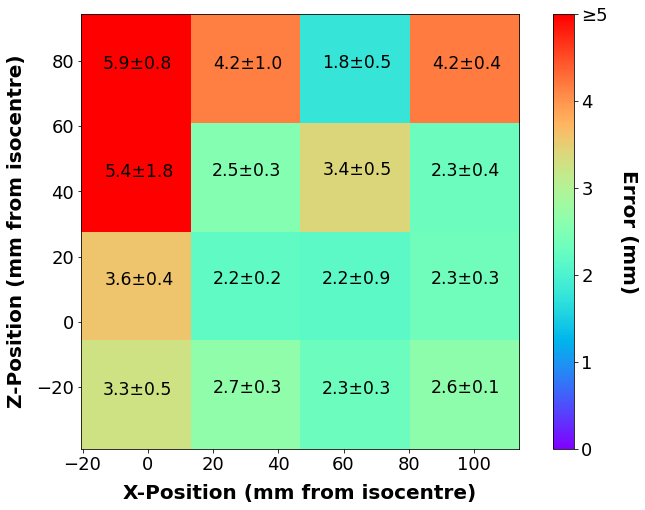

Saving error data from each catheter to: ../reports/export/static/Y0_SRI_Original_centroid_around_peak.h5
Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence SRI_Original, algorithm jpng


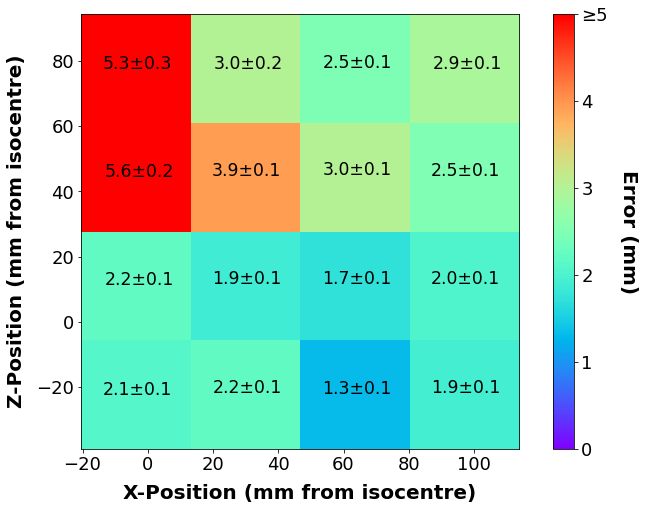

Saving error data from each catheter to: ../reports/export/static/Y0_SRI_Original_jpng.h5
Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


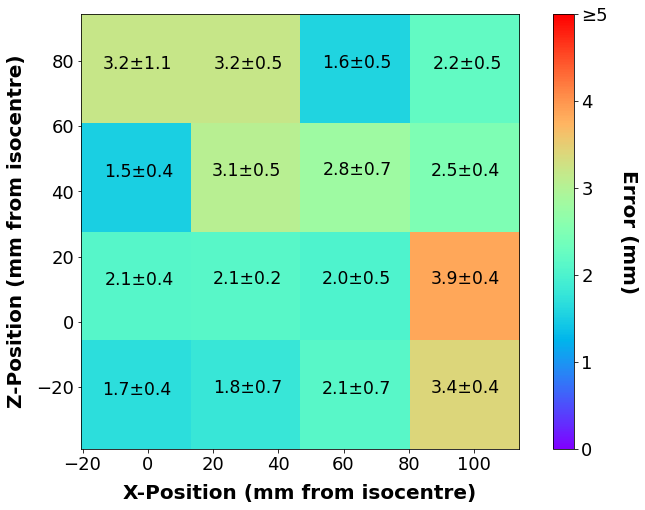

Saving error data from each catheter to: ../reports/export/static/Y0_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Error heatmaps for Y = 45mm
shape of Z: (16,)
Tip Tracking Error @ Y = 45mm sequence FH512_noDither_gradSpoiled, algorithm jpng


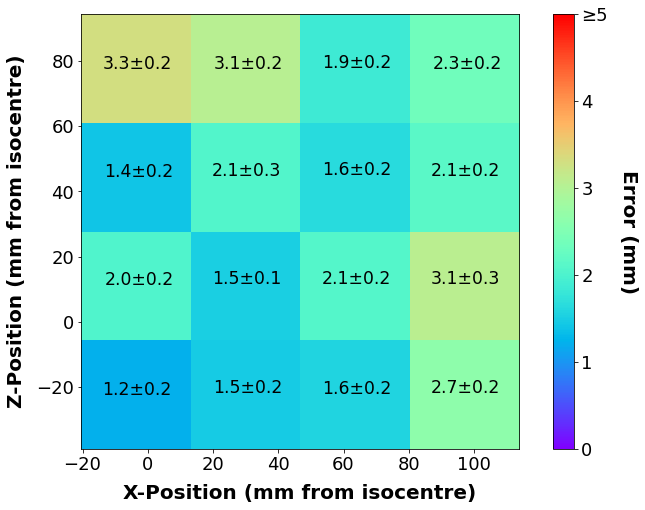

Saving error data from each catheter to: ../reports/export/static/Y0_FH512_noDither_gradSpoiled_jpng.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm centroid_around_peak


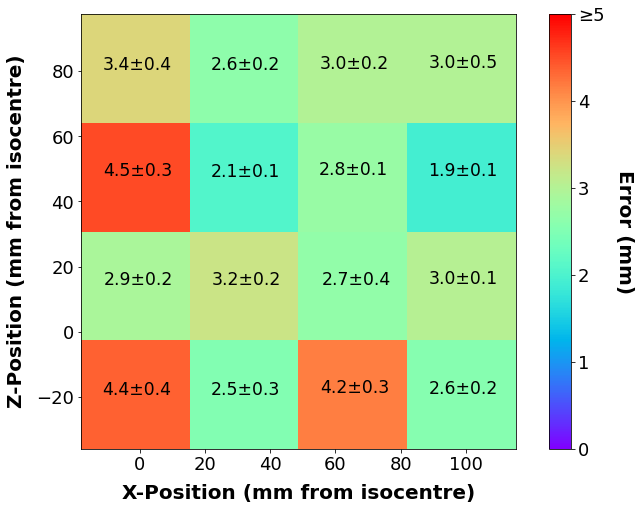

Saving error data from each catheter to: ../reports/export/static/Y1_SRI_Original_centroid_around_peak.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence SRI_Original, algorithm jpng


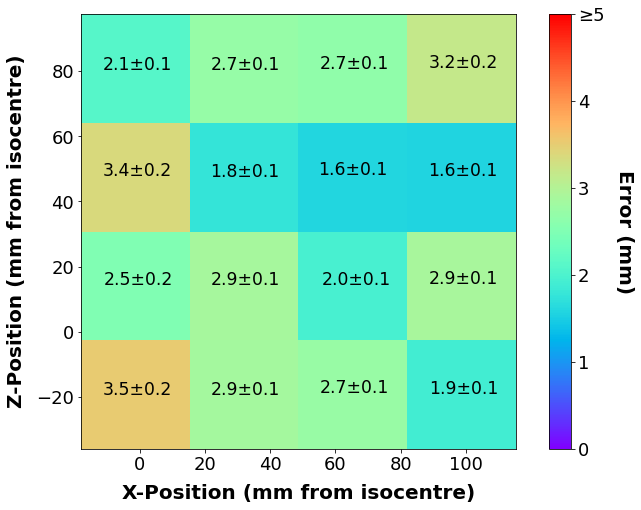

Saving error data from each catheter to: ../reports/export/static/Y1_SRI_Original_jpng.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


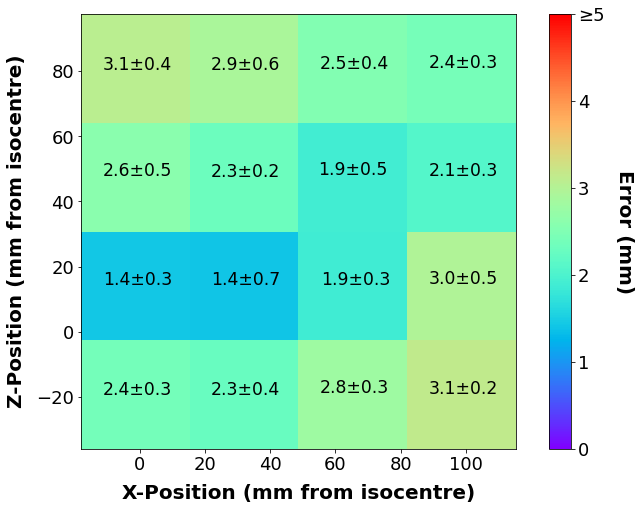

Saving error data from each catheter to: ../reports/export/static/Y1_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Error heatmaps for Y = 20mm
shape of Z: (16,)
Tip Tracking Error @ Y = 20mm sequence FH512_noDither_gradSpoiled, algorithm jpng


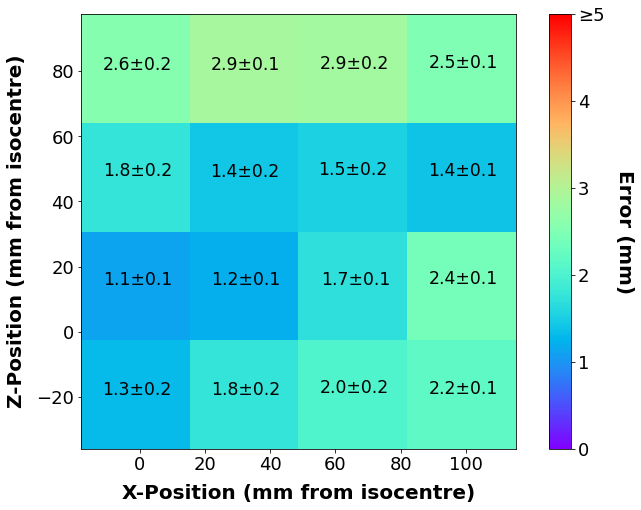

Saving error data from each catheter to: ../reports/export/static/Y1_FH512_noDither_gradSpoiled_jpng.h5
Error heatmaps for Y = -5mm
Adjusting for missing recording for SRI_Original, centroid_around_peak, Y2
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm centroid_around_peak


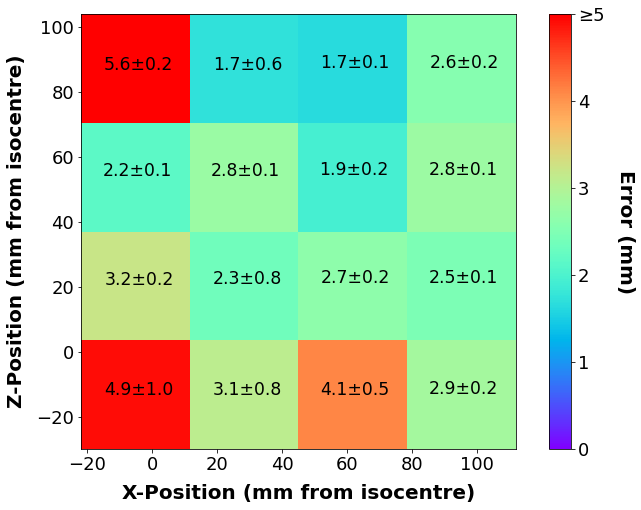

Saving error data from each catheter to: ../reports/export/static/Y2_SRI_Original_centroid_around_peak.h5
Error heatmaps for Y = -5mm
Adjusting for missing recording for SRI_Original, jpng, Y2
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence SRI_Original, algorithm jpng


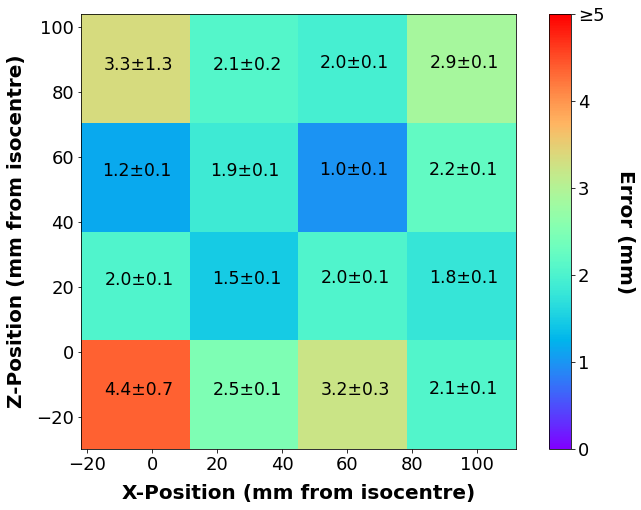

Saving error data from each catheter to: ../reports/export/static/Y2_SRI_Original_jpng.h5
Error heatmaps for Y = -5mm
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm centroid_around_peak


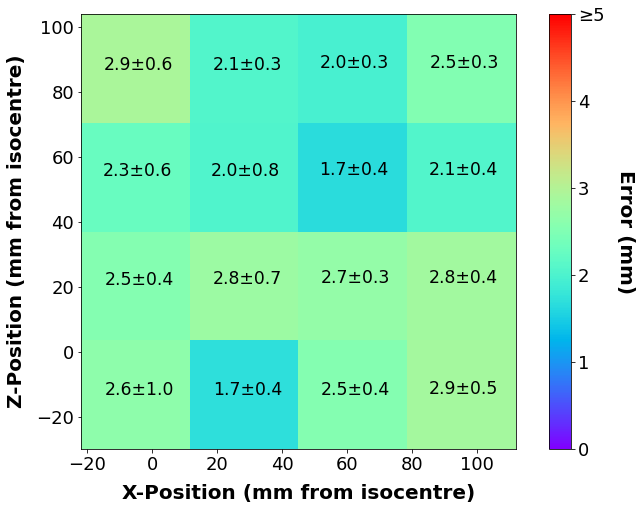

Saving error data from each catheter to: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_centroid_around_peak.h5
Error heatmaps for Y = -5mm
shape of Z: (16,)
Tip Tracking Error @ Y = -5mm sequence FH512_noDither_gradSpoiled, algorithm jpng


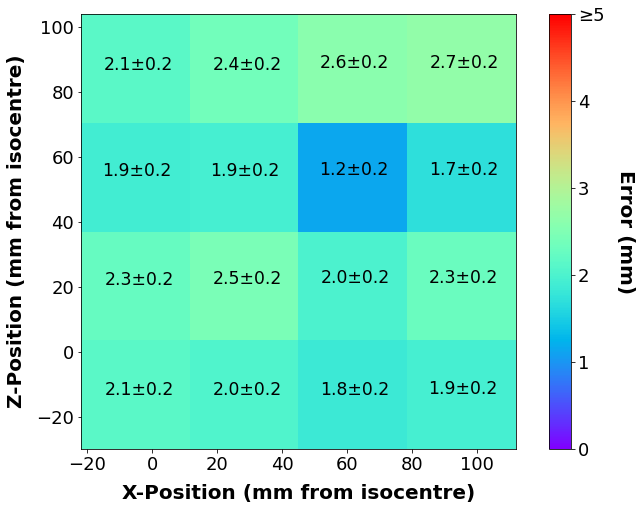

Saving error data from each catheter to: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_jpng.h5


In [9]:
# Display heatmap error plots
for plot_combination in aggregate_plot:
    yloc = plot_combination['Y_Loc']
    print(f'Error heatmaps for {yloc.description}')
    seq = plot_combination['Sequence']
    alg = plot_combination['Algorithm']
    path_dct = plot_combination['Path_Dict']
    main_path = main_paths[yloc.in_suffix]
    # Average the error over catheters
    sum_all_caths = path_dct[main_path[0]][0] + path_dct[main_path[1]][0] + path_dct[main_path[2]][0]
    avg_all_caths = sum_all_caths / 3
    if seq == 'SRI_Original' and yloc.in_suffix == 'Y2':
        # A recording is missing - results in one invalid 0 mm error in the path_dct
        print(f'Adjusting for missing recording for {seq}, {alg}, {yloc.in_suffix}')
        avg_all_caths[1, 2] = avg_all_caths[1, 2] * 3/2.0 # recover total sum, then divide by 2 for mean
    avg_err = avg_all_caths[:, 2]
    stddev = np.sqrt(sum_all_caths[:, 3])

    my_data = np.array([avg_all_caths[:, 0], avg_all_caths[:, 1], avg_err]).T

    X = my_data[:, 0]
    Y = my_data[:, 1]
    Z = my_data[:, 2]
    print(f'shape of Z: {np.shape(Z)}')

    heatmap = static_utils.nonuniform_imshow(X, Y, Z, stddev, numeric=True)
    plt.gca().invert_yaxis()
    plt.xlabel('X-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
    plt.ylabel('Z-Position (mm from isocentre)', fontsize = 20, fontweight = 'bold', labelpad = 10)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    print('Tip Tracking Error @ {2} sequence {0}, algorithm {1}'.format(seq, alg, yloc.description))
    cbar = plt.colorbar(heatmap)
    cbar.ax.set_yticklabels(['0', '1', '2', '3', '4', '\u2265' + '5'])
    cbar.ax.get_yaxis().labelpad = 30
    cbar.ax.tick_params(labelsize = 18)
    cbar.ax.set_ylabel('Error (mm)', rotation = 270, fontsize = 20, fontweight = 'bold')

    if not os.path.isdir('{0}'.format(heatmap_paths[yloc.in_suffix])):
        os.makedirs('{0}'.format(heatmap_paths[yloc.in_suffix]))

    plt.savefig('{0}{1}_{2}_heatmap.png'.format(heatmap_paths[yloc.in_suffix], seq, alg), dpi=300)
    plt.show()
    # Below we save the tip errors from each catheter to hdf5 format
    h5out = '{0}{3}_{1}_{2}.h5'.format(error_path, seq, alg, yloc.in_suffix)
    with h5py.File(h5out, 'w', libver='latest') as f:
        print("Saving error data from each catheter to: " + h5out)
        for k, v in path_dct.items():
            expmt = pathlib.PurePath(k).parts[-1]
            name = 'static_err_' + seq + '_' + alg + '_' + expmt
            f.create_dataset(name, data=v[0])

# Comparisons across Sequences and Algorithms
We plan to compare tip errors from the JPNG and CAP peak-finding algorithms, for each sequence. Then we will compare tip errrors from both the HM & 3P sequences, with both JPNG and CAP algorithms. This will result in four comparisons, so we will use a Bonferroni adjustment for the p-value.

In [10]:
p_val_adj = 0.05 / 4

In [11]:
p_val_adj

0.0125

In [12]:
agg_df  # each row contains the error (bias) and variance for one multi-second recording
        # of one sequence, from one catheter, at one location, processed with one algorithm

,Y_Loc,Sequence,Algorithm,Catheter,Grid_Loc,Mean_Bias,Biases,Variance,Count,GT_X,GT_Z
0,Y0,SRI_Original,centroid_around_peak,C222,1,1.970112,"[1.9833520602399075, 2.0714497764852036, 1.812...",0.003940,337.0,-2.609326,-21.936268
1,Y0,SRI_Original,centroid_around_peak,C222,2,3.175268,"[3.090043110615727, 3.126779341178156, 3.09207...",0.003491,339.0,30.943948,-22.098604
2,Y0,SRI_Original,centroid_around_peak,C222,3,0.948233,"[1.1408342182641895, 0.9749383302433562, 1.095...",0.096054,346.0,64.474602,-22.240331
3,Y0,SRI_Original,centroid_around_peak,C222,4,2.855528,"[2.925006311464213, 2.7307822863905487, 2.9305...",0.002422,340.0,97.597368,-21.155930
4,Y0,SRI_Original,centroid_around_peak,C222,5,2.708824,"[2.7734128719347777, 2.6661149919671536, 2.653...",0.003078,356.0,98.385867,11.853434
...,...,...,...,...,...,...,...,...,...,...,...
571,Y2,FH512_noDither_gradSpoiled,jpng,C306,12,1.977405,"[2.0967337921131093, 2.098694082491882, 2.1577...",0.003875,177.0,96.287750,49.580823
572,Y2,FH512_noDither_gradSpoiled,jpng,C306,13,1.635901,"[1.7734196051076967, 1.7106319403999157, 1.726...",0.005339,182.0,96.215453,82.892297
573,Y2,FH512_noDither_gradSpoiled,jpng,C306,14,1.933651,"[2.0415259202574005, 2.3109337099813385, 2.288...",0.010329,179.0,62.903314,82.553024
574,Y2,FH512_noDither_gradSpoiled,jpng,C306,15,1.887507,"[2.0088087950072353, 2.0332241908185344, 2.152...",0.004623,180.0,29.271801,82.425704


## JPNG vs CAP
### HM
Compare JPNG and CAP algorithms in the hadamard-multiplexed sequence

In [13]:
hm_df = agg_df[agg_df['Sequence']=='FH512_noDither_gradSpoiled']

#### HM mean bias comparison
Compare JPNG and CAP algorithms in the hadamard-multiplexed sequence, using the mean biases from each 3d grid location - this should be an average of the biases from each catheter:

In [14]:
hm_cap_mean_errors = hm_df[hm_df['Algorithm']=='centroid_around_peak']['Mean_Bias'].values

In [15]:
hm_jpng_mean_errors = hm_df[hm_df['Algorithm']=='jpng']['Mean_Bias'].values

In [16]:
len(hm_cap_mean_errors)

144

In [17]:
len(hm_jpng_mean_errors)

144

In [18]:
hm_cap_mean_errors = []
hm_jpng_mean_errors = []

In [19]:
y_locs = hm_df['Y_Loc'].unique() # unique(): returned in order of appearance

In [20]:
grid_locs = hm_df['Grid_Loc'].unique()

In [21]:
for y in y_locs:
    for g in grid_locs:
        cap_mean = hm_df[(hm_df['Algorithm']=='centroid_around_peak') & (hm_df['Y_Loc']==y) & (hm_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        jpng_mean = hm_df[(hm_df['Algorithm']=='jpng') & (hm_df['Y_Loc']==y) & (hm_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        hm_cap_mean_errors.append(cap_mean)
        hm_jpng_mean_errors.append(jpng_mean)

Sanity check that we now have the correct number of 3d locations:

In [22]:
len(hm_cap_mean_errors)

48

In [23]:
np.mean(hm_cap_mean_errors)

2.4049888228245675

In [24]:
np.std(hm_cap_mean_errors)

0.5549971837619325

In [25]:
len(hm_jpng_mean_errors)

48

In [26]:
np.mean(hm_jpng_mean_errors)

2.0347038503902968

In [27]:
np.std(hm_jpng_mean_errors)

0.5361689098036709

In [28]:
w, p = stats.wilcoxon(x=hm_jpng_mean_errors,y=hm_cap_mean_errors,alternative='less')

In [29]:
p

1.530169880194031e-06

In [30]:
import sys
sys.path.append('../')
import Invivo_Tracking.displacement_utils as disp_utils

Static Experiment HM Sequence: CAP vs JPNG Tip Error


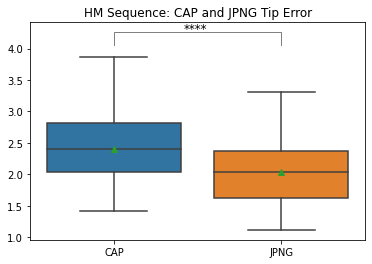

In [31]:
ax = sns.boxplot(data=[hm_cap_mean_errors,hm_jpng_mean_errors],orient='v',showmeans=True)
print('Static Experiment HM Sequence: CAP vs JPNG Tip Error')
max_y = max(np.max(hm_cap_mean_errors),np.max(hm_jpng_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('HM Sequence: CAP and JPNG Tip Error')
ax.set_xticklabels(['CAP','JPNG'])
plt.savefig('../reports/figures/static/HM-capVsJpng-meantipErr.pdf',dpi=600)
plt.show()

### 3P Sequence
Compare JPNG and CAP algorithms in the three-projection sequence

In [32]:
proj_df = agg_df[agg_df['Sequence']=='SRI_Original']

#### 3P mean bias comparison
Compare JPNG and CAP algorithms in the three-projection sequence, using the mean biases from each 3d grid location - this should be an average of the biases from each catheter:

In [33]:
proj_cap_mean_errors = []
proj_jpng_mean_errors = []

In [34]:
for y in y_locs:
    for g in grid_locs:
        cap_mean = proj_df[(proj_df['Algorithm']=='centroid_around_peak') & (proj_df['Y_Loc']==y) & (proj_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        jpng_mean = proj_df[(proj_df['Algorithm']=='jpng') & (proj_df['Y_Loc']==y) & (proj_df['Grid_Loc']==g)]['Mean_Bias'].mean()
        proj_cap_mean_errors.append(cap_mean)
        proj_jpng_mean_errors.append(jpng_mean)

In [35]:
w, p = stats.wilcoxon(x=proj_jpng_mean_errors,y=proj_cap_mean_errors,alternative='less')

In [36]:
p

9.725942006084667e-07

In [37]:
np.mean(proj_cap_mean_errors)

3.0547507652106027

In [38]:
np.std(proj_cap_mean_errors)

1.0067931077309

In [39]:
np.mean(proj_jpng_mean_errors)

2.509016114186541

In [40]:
np.std(proj_jpng_mean_errors)

0.9281836374657682

Static Experiment 3P Sequence: CAP vs JPNG Tip Error


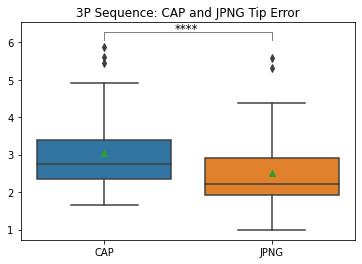

In [41]:
ax = sns.boxplot(data=[proj_cap_mean_errors,proj_jpng_mean_errors],orient='v',showmeans=True)
print('Static Experiment 3P Sequence: CAP vs JPNG Tip Error')
max_y = max(np.max(proj_cap_mean_errors),np.max(proj_jpng_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('3P Sequence: CAP and JPNG Tip Error')
ax.set_xticklabels(['CAP','JPNG'])
plt.savefig('../reports/figures/static/3P-capVsJpng-meantipErr.pdf',dpi=600)
plt.show()

## HM vs 3P
### JPNG
Compare tip errors from hadamard and three-projection sequences for JPNG algorithm.

In [42]:
jpng_df = agg_df[agg_df['Algorithm']=='jpng'].copy()

#### JPNG: compare the means 
Compare mean tip errors from hadamard and three-projection sequences for JPNG algorithm: get the means from each 3d grid location, from all catheters, using Mean_Bias

In [43]:
jpng_3P_mean_errors = []
jpng_HM_mean_errors = []
for y in y_locs:
    for g in grid_locs:
        proj_biases = jpng_df[(jpng_df['Sequence']=='SRI_Original') & (jpng_df['Y_Loc']==y) & (jpng_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        hm_biases = jpng_df[(jpng_df['Sequence']=='FH512_noDither_gradSpoiled') & (jpng_df['Y_Loc']==y) & (jpng_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        proj_biases = proj_biases[~np.isnan(proj_biases)]
        hm_biases = hm_biases[~np.isnan(hm_biases)]
        jpng_3P_mean_errors.append(np.mean(proj_biases))
        jpng_HM_mean_errors.append(np.mean(hm_biases))

In [44]:
len(jpng_3P_mean_errors)

48

In [45]:
np.mean(jpng_3P_mean_errors)

2.509016114186541

In [46]:
np.std(jpng_3P_mean_errors)

0.9281836374657682

In [47]:
np.mean(jpng_HM_mean_errors)

2.0347038503902968

In [48]:
np.std(jpng_HM_mean_errors)

0.5361689098036709

In [49]:
w, p = stats.wilcoxon(x=jpng_HM_mean_errors,y=jpng_3P_mean_errors,alternative='less')

In [50]:
p

0.002474818052833303

In [51]:
p_val_adj

0.0125

Static Experiment JPNG Algorithm: 3P and HM Mean Tip Error


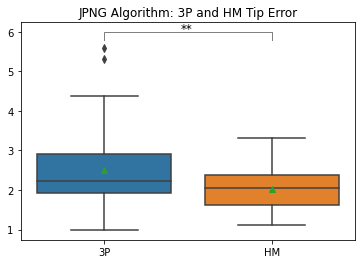

In [52]:
ax = sns.boxplot(data=[jpng_3P_mean_errors,jpng_HM_mean_errors],orient='v',showmeans=True)
print('Static Experiment JPNG Algorithm: 3P and HM Mean Tip Error')
max_y = max(np.max(jpng_3P_mean_errors),np.max(jpng_HM_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('JPNG Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/JPNG-3PvsHM-mean_boxplot.pdf',dpi=600)
plt.show()

## CAP
Compare tip errors from hadamard and three-projection sequences for the centroid-around-peak algorithm.

In [53]:
cap_df = agg_df[agg_df['Algorithm']=='centroid_around_peak'].copy()

#### CAP: compare the means 
Compare mean tip errors from hadamard and three-projection sequences for CAP algorithm: get the means from each 3d grid location, from all catheters, using the Mean_Bias column

In [54]:
cap_3P_mean_errors = []
cap_HM_mean_errors = []
for y in y_locs:
    for g in grid_locs:
        proj_biases = cap_df[(cap_df['Sequence']=='SRI_Original') & (cap_df['Y_Loc']==y) & (cap_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        hm_biases = cap_df[(cap_df['Sequence']=='FH512_noDither_gradSpoiled') & (cap_df['Y_Loc']==y) & (cap_df['Grid_Loc']==g)]['Mean_Bias'].ravel()
        proj_biases = proj_biases[~np.isnan(proj_biases)]
        hm_biases = hm_biases[~np.isnan(hm_biases)]
        cap_3P_mean_errors.append(np.mean(proj_biases))
        cap_HM_mean_errors.append(np.mean(hm_biases))

In [55]:
np.mean(cap_3P_mean_errors)

3.0547507652106027

In [56]:
np.std(cap_3P_mean_errors)

1.0067931077309

In [57]:
np.mean(cap_HM_mean_errors)

2.4049888228245675

In [58]:
np.std(cap_HM_mean_errors)

0.5549971837619325

In [59]:
w, p = stats.wilcoxon(x=cap_HM_mean_errors,y=cap_3P_mean_errors,alternative='less')

In [60]:
p

0.00016547173050728041

Static Experiment CAP Algorithm: 3P and HM Mean Tip Error


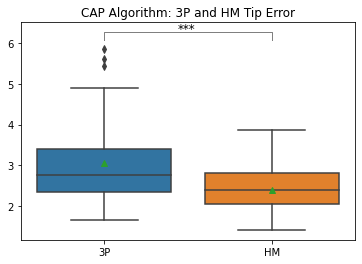

In [61]:
ax = sns.boxplot(data=[cap_3P_mean_errors,cap_HM_mean_errors],orient='v',showmeans=True)
print('Static Experiment CAP Algorithm: 3P and HM Mean Tip Error')
max_y = max(np.max(cap_3P_mean_errors),np.max(cap_HM_mean_errors))
if p < p_val_adj: # draw a significance line
    star_str = disp_utils.get_p_stars(p)
    starline_y = max_y
    ax.plot([0, 0, 1, 1], [starline_y+0.2, starline_y+0.4, starline_y+0.4, starline_y+0.2], linewidth=1, color='grey')
    ax.text(0.49, starline_y+0.4, star_str, ha='center', fontsize=12)
ax.set_title('CAP Algorithm: 3P and HM Tip Error')
ax.set_xticklabels(['3P','HM'])
plt.savefig('../reports/figures/static/CAP-3PvsHM-mean_boxplot.pdf',dpi=600)
plt.show()

# HDF5 Exports
Error data has been saved to hdf5 (Hierarchical Data Format) files, one file for each sequence and algorithm combination. These can be read using your own code for further analysis, as shown in the code snippet below.

We check that we can open and read the most recent hdf5 file. The catheter error arrays are stored as datasets within this file.

Output the first dataset as an array from this file. This is a 2d array containing the tip errors for this catheter.

For each grid position:
the ground truth X coordinate, Z coordinate, bias (tip error) in mm, tip variance in mm (in that order)

So, there are 16 elements arranged like:

`[ [GT_x_pos0, GT_z_pos0, bias_pos0, variance_pos0], [GT_x_pos1, GT_z_pos1, bias_pos1, variance_pos1], ... [GT_x_pos15, GT_z_pos15, bias_pos15, variance_pos2] ]`

In [62]:
with h5py.File(h5out, 'r', libver='latest') as f:
    first_dataset = list(f.keys())[0]

    print("Looking at catheter tip errors for " + first_dataset \
          + "\n from the file: " + h5out)
    
    # Can also use h5py dataset object: ds_obj = f[a_group_key]
    # The 2d array contains the tip error for this catheter
    ds_arr = f[first_dataset][()]  # returns as a numpy array
    print(ds_arr)

Looking at catheter tip errors for static_err_FH512_noDither_gradSpoiled_jpng_trackTest-7Jan2022-C306-Y2
 from the file: ../reports/export/static/Y2_FH512_noDither_gradSpoiled_jpng.h5
[[-3.80553565e+00 -1.87287835e+01  3.01430331e+00  1.90963368e-02
   1.78000000e+02]
 [ 2.96936945e+01 -1.86500552e+01  2.52192775e+00  6.63732145e-03
   1.75000000e+02]
 [ 6.26533407e+01 -1.88988546e+01  1.75275943e+00  1.70920807e-02
   1.75000000e+02]
 [ 9.62574016e+01 -1.85214438e+01  1.59943733e+00  3.41239821e-03
   1.75000000e+02]
 [ 9.64131762e+01  1.65016458e+01  2.20761256e+00  6.07945832e-03
   1.80000000e+02]
 [ 6.30397218e+01  1.63046923e+01  1.77709769e+00  1.32166745e-02
   1.77000000e+02]
 [ 2.93706112e+01  1.61286079e+01  2.81292745e+00  4.22867173e-02
   1.83000000e+02]
 [-3.41449462e+00  1.57894111e+01  3.22256336e+00  8.85141825e-03
   1.75000000e+02]
 [-4.17528641e+00  4.91897834e+01  1.17789751e+00  6.27023489e-03
   1.75000000e+02]
 [ 2.84294862e+01  4.92649623e+01  1.23534200e+00  